# Tanager Mangrove Mapping - 01b Multispectral-Equivalent Preprocessing

| | |
|---|---|
| **Authors**     | Muhammad Wahyu Ramadhan, Athar Abdurrahman B., Diniyarti |
| **Competition** | Planet Tanager Open Data Competition 2026 |
| **Topic**       | Transferable Mangrove Extent and Biomass Mapping Using Adaptive Spectral Thresholds |
| **Date**        | July 2026 |

---

**Scope (Scenario B — journal publication only):** Load Tanager HDF5, convolve with Sentinel-2A SRF to produce multispectral-equivalent bands (B3, B4, B8, B11), compute reduced feature stack (NDMI, MVI, MNDWI, SAVI), generate pseudo-labels via adaptive threshold constrained to coastal candidate zone. REIP and EMI excluded by design.

**Relationship to Scenario A:** Pseudo-label generation logic (adaptive threshold + coastal candidate mask + MVI AND NDMI rule) is held constant between scenarios to isolate the effect of the feature stack.

## 0. Environment Setup

In [1]:
# !pip install h5py scikit-image geopandas rasterio matplotlib openpyxl xarray scipy


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import sys
import json
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

# ============================================================
# Project root and paths
# ============================================================
ROOT           = Path('/content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping')
DATA_RAW       = ROOT / 'data' / 'raw'
DATA_PROC      = ROOT / 'data' / 'processed'
DATA_PROC_S2EQ = ROOT / 'data' / 'processed_s2eq'
DATA_SRF       = ROOT / 'data' / 'sentinel2_srf'
OUT_RESULTS    = ROOT / 'outputs' / 'results'
OUT_FIGURES    = ROOT / 'outputs' / 'figures'

for d in (DATA_PROC_S2EQ, OUT_RESULTS, OUT_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))

# ============================================================
# Reload src modules
# ============================================================
import src.preprocessing       as _pre
import src.classification      as _cls
import src.spectral_resampling as _srf
importlib.reload(_pre)
importlib.reload(_cls)
importlib.reload(_srf)

from src.preprocessing import (
    load_hdf5,
    compute_coastal_candidate_mask,
    apply_adaptive_threshold,
)
from src.classification import generate_pseudo_labels
from src.spectral_resampling import (
    S2_TARGET_BANDS,
    load_sentinel2_srf,
    resample_hyperspectral_to_s2,
    compute_scenario_b_indices,
    write_scenario_b_outputs,
)

# ============================================================
# Site registry (same as Scenario A)
# ============================================================
SITES = {
    'sangatta'   : '20250302_030003_92_4001',
    'gujarat'    : '20250311_061550_53_4001',
    'elsalvador' : '20250223_165546_32_4001',
    'belize'     : '20250824_171857_84_4001',
    'australia'  : '20250608_014315_58_4001',
}

SRF_FILE = DATA_SRF / 'COPE-GSEG-EOPG-TN-15-0007 - Sentinel-2 Spectral Response Functions 2024 - 4.0.xlsx'

print(f'ROOT           : {ROOT}')
print(f'Sites          : {list(SITES.keys())}')
print(f'SRF file       : {SRF_FILE.name}')
print(f'S2 bands used  : {list(S2_TARGET_BANDS.keys())} (B3, B4, B8, B11)')


ROOT           : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping
Sites          : ['sangatta', 'gujarat', 'elsalvador', 'belize', 'australia']
SRF file       : COPE-GSEG-EOPG-TN-15-0007 - Sentinel-2 Spectral Response Functions 2024 - 4.0.xlsx
S2 bands used  : ['green', 'red', 'nir', 'swir1'] (B3, B4, B8, B11)


## 1. Load Sentinel-2 Spectral Response Function

Source: ESA COPE-GSEG-EOPG-TN-15-0007 v4.0 (2024). Platform: Sentinel-2A.

In [4]:
print('Loading Sentinel-2A SRF...')
srf_dict = load_sentinel2_srf(SRF_FILE, platform='S2A')
print(f'\n  SRF loaded     : {len(srf_dict)} bands (green, red, nir, swir1)')


Loading Sentinel-2A SRF...
  SRF S2A green : 538-583 nm, peak=560 nm, 46 points
  SRF S2A red   : 646-684 nm, peak=654 nm, 39 points
  SRF S2A nir   : 760-907 nm, peak=789 nm, 137 points
  SRF S2A swir1 : 1539-1682 nm, peak=1639 nm, 144 points

  SRF loaded     : 4 bands (green, red, nir, swir1)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


## 2. Per-Site Resampling and Index Computation

For each site: load HDF5 (426 bands) -> convolve with S2A SRF -> compute NDMI, MVI, MNDWI, SAVI -> write to `data/processed_s2eq/{site_key}_s2eq_indices.tif`. CRS and transform inherited from Scenario A `*_bands.tif`.

In [5]:
# ============================================================
# Main resampling loop -- all sites
# ============================================================
for site, scene_id in SITES.items():
    print(f'\n{"="*60}')
    print(f'  Site           : {site}  ({scene_id})')
    print(f'{"="*60}')

    h5_path       = DATA_RAW  / f'{site}_{scene_id}_ortho_sr_hdf5.h5'
    reference_tif = DATA_PROC / f'{site}_{scene_id}_bands.tif'
    site_key      = f'{site}_{scene_id}'

    hdf5_data = load_hdf5(str(h5_path))

    resampled = resample_hyperspectral_to_s2(
        hdf5_data['reflectance'],
        hdf5_data['wavelengths'],
        srf_dict,
    )

    indices_b = compute_scenario_b_indices(resampled)

    write_scenario_b_outputs(
        indices_b,
        reference_tif = reference_tif,
        out_dir       = DATA_PROC_S2EQ,
        site_key      = site_key,
    )



  Site           : sangatta  (20250302_030003_92_4001)
  HDF5 loaded     : sangatta_20250302_030003_92_4001_ortho_sr_hdf5.h5
  Shape (B,H,W)   : (426, 850, 810)
  CRS             : EPSG:32650
  Pixel size      : 30.0 m
  Wavelength range: 380-2500 nm
  Resampled green : 9 Tanager bands used, mean R = 0.0711
  Resampled red   : 7 Tanager bands used, mean R = 0.0449
  Resampled nir   : 29 Tanager bands used, mean R = 0.2259
  Resampled swir1 : 29 Tanager bands used, mean R = 0.1405
  NDMI  : min=-14.2903, max=3.0914, mean=0.3100
  MVI   : min=-29704.3770, max=268748.8750, mean=49.8546
  MNDWI : min=-8.8228, max=3.1662, mean=0.0708
  SAVI  : min=-0.2348, max=0.8205, mean=0.2800
  Scenario B output : sangatta_20250302_030003_92_4001_s2eq_indices.tif
  Bands (in order)  : ['NDMI', 'MVI', 'MNDWI', 'SAVI']

  Site           : gujarat  (20250311_061550_53_4001)
  HDF5 loaded     : gujarat_20250311_061550_53_4001_ortho_sr_hdf5.h5
  Shape (B,H,W)   : (426, 795, 799)
  CRS             : EPSG:326

## 3. Adaptive Threshold, Candidate Mask, and Pseudo-Label Generation

Reuses `compute_coastal_candidate_mask`, `apply_adaptive_threshold`, and `generate_pseudo_labels` from `src/` unchanged. Only difference from Scenario A: input feature stack (4 indices instead of 6).

**Note on MVI thresholds:** Scenario B MVI thresholds are systematically higher than Scenario A because SRF-averaged NIR (B8, 760-907 nm) is broader than discrete 860 nm extraction. `force_otsu` correctly adapts to each distribution independently.

Outputs per site:
- `data/processed_s2eq/candidate_s2eq_{site}_{scene_id}.tif`
- `data/processed_s2eq/{site_key}_s2eq_labels.tif`
- `outputs/results/thresholds_s2eq_{site}_{scene_id}.json`

In [6]:
# ============================================================
# Adaptive threshold + candidate mask + pseudo-label -- all sites
# ============================================================
all_thresholds_b = {}

for site, scene_id in SITES.items():
    print(f'\n{"="*60}')
    print(f'  Site           : {site}  ({scene_id})')
    print(f'{"="*60}')

    site_key  = f'{site}_{scene_id}'
    s2eq_path = DATA_PROC_S2EQ / f'{site_key}_s2eq_indices.tif'

    with rasterio.open(s2eq_path) as src:
        arr    = src.read().astype(np.float32)
        data_b = {'transform': src.transform, 'crs': src.crs}

    indices_b = {
        'NDMI'  : arr[0],
        'MVI'   : arr[1],
        'MNDWI' : arr[2],
        'SAVI'  : arr[3],
    }

    # 1. Coastal candidate mask
    candidate_mask = compute_coastal_candidate_mask(data_b, indices_b)

    # Save candidate mask
    cand_path = DATA_PROC_S2EQ / f'candidate_s2eq_{site}_{scene_id}.tif'
    with rasterio.open(
        cand_path, 'w', driver='GTiff',
        height=candidate_mask.shape[0], width=candidate_mask.shape[1],
        count=1, dtype='uint8',
        crs=data_b['crs'], transform=data_b['transform'],
        compress='lzw',
    ) as dst:
        dst.write(candidate_mask.astype(np.uint8), 1)
    print(f'  Candidate saved    : {cand_path.name}')

    # 2. Adaptive threshold
    thresholds = apply_adaptive_threshold(
        indices_b,
        scene_id=scene_id,
        candidate_mask=candidate_mask,
        force_otsu_indices=['MVI'],
    )

    thresh_path = OUT_RESULTS / f'thresholds_s2eq_{site}_{scene_id}.json'
    with open(thresh_path, 'w') as f:
        json.dump(
            {k: float(v) for k, v in thresholds.items()
             if v is not None and np.isfinite(v)},
            f, indent=2
        )
    print(f'  Thresholds saved   : {thresh_path.name}')

    all_thresholds_b[site] = thresholds

    # 3. Pseudo-labels
    labels = generate_pseudo_labels(
        indices_b, thresholds, candidate_mask=candidate_mask,
    )

    label_path = DATA_PROC_S2EQ / f'{site_key}_s2eq_labels.tif'
    with rasterio.open(
        label_path, 'w', driver='GTiff',
        height=labels.shape[0], width=labels.shape[1],
        count=1, dtype='int8',
        crs=data_b['crs'], transform=data_b['transform'],
        compress='lzw', nodata=-1,
    ) as dst:
        dst.write(labels, 1)
    print(f'  Pseudo-labels saved: {label_path.name}')



  Site           : sangatta  (20250302_030003_92_4001)
  Coastal candidate mask:
  water_t  (MNDWI)    : 0.1455
  veg_t    (SAVI)     : 0.2990
  buffer_t (otsu)     : 44.8 px (~1343 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 59,132 (8.6%)
  Candidate saved    : candidate_s2eq_sangatta_20250302_030003_92_4001.tif

  Adaptive thresholds (domain=candidate-zone) -- scene: 20250302_030003_92_4001
  NDMI    : threshold = 0.2530  [bimodal]
  MVI     : threshold = 48.0697  [otsu_forced]
  MNDWI   : threshold = -0.4681  [bimodal]
  SAVI    : threshold = 0.6178  [bimodal]
  Thresholds saved   : thresholds_s2eq_sangatta_20250302_030003_92_4001.json
  Pseudo-labels generated:
  mangrove     : 13,018 px
  non-mangrove : 484,779 px
  invalid      : 190,703 px
  (constrained to coastal candidate zone)
  Pseudo-labels saved: sangatta_20250302_030003_92_4001_s2eq_labels.tif

  Site           : gujarat  (20250311_061550_53_4001)
  Coastal candidate mask:
  water_

## 4. Diagnostic Preview -- Sangatta Candidate Mask

4-panel visualization of coastal candidate mask components on the training site (Sangatta). Same layout as `01_preprocessing.ipynb` Section 6 for direct visual comparison against Scenario A.

Panels: water mask (MNDWI Otsu), vegetation mask (SAVI Otsu), distance-from-water, final candidate zone.

  Coastal candidate mask:
  water_t  (MNDWI)    : 0.1455
  veg_t    (SAVI)     : 0.2990
  buffer_t (otsu)     : 44.8 px (~1343 m)
  buffer_t (capped)   : 16.7 px (~500 m)  [cap applied]
  candidate pixels    : 59,132 (8.6%)


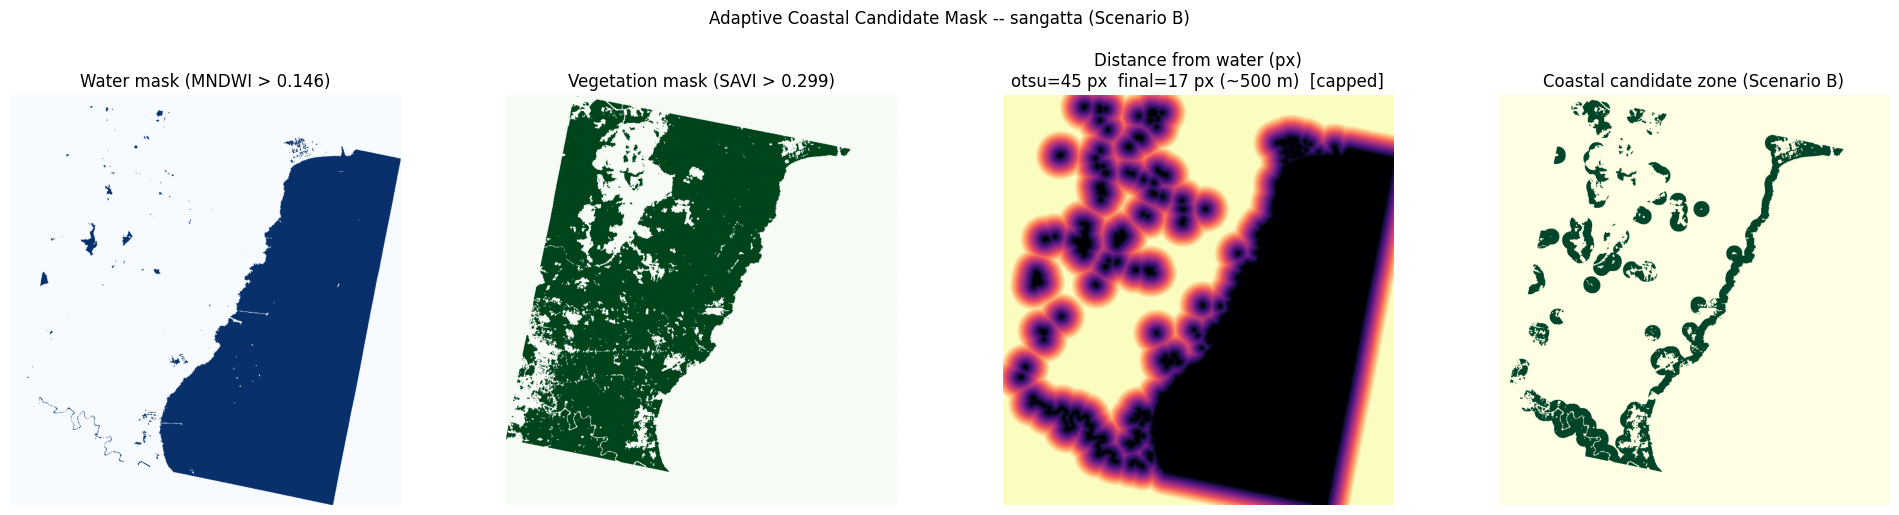

In [7]:
# ============================================================
# Recompute Sangatta candidate mask with diagnostics for preview
# ============================================================
SITE      = 'sangatta'
SCENE_ID  = SITES[SITE]
site_key  = f'{SITE}_{SCENE_ID}'
s2eq_path = DATA_PROC_S2EQ / f'{site_key}_s2eq_indices.tif'

with rasterio.open(s2eq_path) as src:
    arr    = src.read().astype(np.float32)
    data_b = {'transform': src.transform, 'crs': src.crs}

indices_b = {
    'NDMI'  : arr[0],
    'MVI'   : arr[1],
    'MNDWI' : arr[2],
    'SAVI'  : arr[3],
}

candidate_mask, candidate_diag = compute_coastal_candidate_mask(
    data_b, indices_b, return_diagnostics=True,
)

# ============================================================
# Diagnostic plot -- candidate mask components
# ============================================================
capped_label = '  [capped]' if candidate_diag['buffer_capped'] else ''

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(candidate_diag['water_mask'], cmap='Blues')
axes[0].set_title(f'Water mask (MNDWI > {candidate_diag["water_t"]:.3f})')
axes[0].axis('off')

axes[1].imshow(candidate_diag['veg_mask'], cmap='Greens')
axes[1].set_title(f'Vegetation mask (SAVI > {candidate_diag["veg_t"]:.3f})')
axes[1].axis('off')

axes[2].imshow(candidate_diag['dist_px'], cmap='magma',
               vmax=candidate_diag['buffer_t_px']*3)
axes[2].set_title(f'Distance from water (px)\n'
                  f'otsu={candidate_diag["buffer_otsu_px"]:.0f} px  '
                  f'final={candidate_diag["buffer_t_px"]:.0f} px '
                  f'(~{candidate_diag["buffer_t_m"]:.0f} m){capped_label}')
axes[2].axis('off')

axes[3].imshow(candidate_mask, cmap='YlGn')
axes[3].set_title('Coastal candidate zone (Scenario B)')
axes[3].axis('off')

plt.suptitle(f'Adaptive Coastal Candidate Mask -- {SITE} (Scenario B)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_FIGURES / f'candidate_mask_s2eq_{SITE}.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 5. Threshold Comparison: Scenario A vs Scenario B

NDMI, MNDWI, SAVI diffs expected < 0.05. MVI diffs expected large due to SRF broadening of NIR bandpass.

In [8]:
# ============================================================
# Compare Scenario A vs B thresholds per site per index
# ============================================================
rows = []
for site, scene_id in SITES.items():
    thresh_a_path = OUT_RESULTS / f'thresholds_{site}_{scene_id}.json'
    if not thresh_a_path.exists():
        print(f'  Scenario A thresholds not found for {site} -- skipping')
        continue
    with open(thresh_a_path) as f:
        thresh_a = json.load(f)

    thresh_b = all_thresholds_b.get(site, {})

    for idx in ['NDMI', 'MVI', 'MNDWI', 'SAVI']:
        t_a = thresh_a.get(idx, None)
        t_b = thresh_b.get(idx, None)
        rows.append({
            'site'        : site,
            'index'       : idx,
            'threshold_A' : round(t_a, 4) if t_a is not None else None,
            'threshold_B' : round(t_b, 4) if t_b is not None else None,
            'diff_B_A'    : round(t_b - t_a, 4) if (t_a and t_b) else None,
        })

df_thresh = pd.DataFrame(rows)
print('\n  Threshold comparison -- Scenario A vs B:')
print(df_thresh.to_string(index=False))
df_thresh.to_csv(OUT_RESULTS / 'threshold_comparison_A_vs_B.csv', index=False)
print('\n  Saved : threshold_comparison_A_vs_B.csv')



  Threshold comparison -- Scenario A vs B:
      site index  threshold_A  threshold_B  diff_B_A
  sangatta  NDMI       0.2464       0.2530    0.0066
  sangatta   MVI       4.0449      48.0697   44.0248
  sangatta MNDWI      -0.4707      -0.4681    0.0025
  sangatta  SAVI       0.6209       0.6178   -0.0031
   gujarat  NDMI      -0.0661      -0.0551    0.0110
   gujarat   MVI       5.5215      11.3975    5.8760
   gujarat MNDWI      -0.3404      -0.3400    0.0003
   gujarat  SAVI       0.1143       0.1038   -0.0105
elsalvador  NDMI       0.4903       0.5148    0.0245
elsalvador   MVI       4.2567      64.7035   60.4467
elsalvador MNDWI      -0.3781      -0.2421    0.1360
elsalvador  SAVI       0.4724       0.4580   -0.0144
    belize  NDMI       0.3697       0.3879    0.0182
    belize   MVI       4.4771      23.7909   19.3137
    belize MNDWI      -0.3788      -0.3681    0.0107
    belize  SAVI       0.5819       0.5778   -0.0041
 australia  NDMI       0.4150       0.4661    0.0511
 a

## 6. Candidate Mask IoU: Scenario A vs Scenario B

Intersection over Union of coastal candidate masks between scenarios. High IoU (> 0.9) supports the claim that Scenario A vs B comparison isolates the effect of feature stack, not spatial extent. Low IoU would indicate SRF resampling shifts the mask geometry itself, confounding the interpretation.

**Requires Scenario A candidate masks at:** `data/processed/candidate_{site}_{scene_id}.tif`

In [9]:
# ============================================================
# IoU of candidate masks per site: Scenario A vs B
# ============================================================
rows = []
for site, scene_id in SITES.items():
    cand_a_path = DATA_PROC      / f'candidate_{site}_{scene_id}.tif'
    cand_b_path = DATA_PROC_S2EQ / f'candidate_s2eq_{site}_{scene_id}.tif'

    if not cand_a_path.exists():
        print(f'  Scenario A candidate mask not found for {site} -- skipping')
        continue
    if not cand_b_path.exists():
        print(f'  Scenario B candidate mask not found for {site} -- skipping')
        continue

    with rasterio.open(cand_a_path) as src:
        mask_a = src.read(1).astype(bool)
    with rasterio.open(cand_b_path) as src:
        mask_b = src.read(1).astype(bool)

    intersection = int((mask_a & mask_b).sum())
    union        = int((mask_a | mask_b).sum())
    iou          = intersection / union if union > 0 else 0.0

    rows.append({
        'site'         : site,
        'px_A'         : int(mask_a.sum()),
        'px_B'         : int(mask_b.sum()),
        'intersection' : intersection,
        'union'        : union,
        'IoU'          : round(iou, 4),
    })

df_iou = pd.DataFrame(rows)
print('\n  Candidate mask IoU -- Scenario A vs B:')
print(df_iou.to_string(index=False))
df_iou.to_csv(OUT_RESULTS / 'candidate_mask_iou_A_vs_B.csv', index=False)
print('\n  Saved : candidate_mask_iou_A_vs_B.csv')



  Candidate mask IoU -- Scenario A vs B:
      site   px_A   px_B  intersection  union    IoU
  sangatta  57014  59132         56797  59349 0.9570
   gujarat 137506 137366        135910 138962 0.9780
elsalvador 115363 115715        114785 116293 0.9870
    belize 105739 107159        104653 108245 0.9668
 australia 122740 121089        119871 123958 0.9670

  Saved : candidate_mask_iou_A_vs_B.csv


## 7. Pseudo-Label Count Comparison: Scenario A vs Scenario B

Compare mangrove pixel count per site between scenarios. Requires Scenario A labels at `data/processed/{site_key}_labels.tif` (adjust path if naming differs).

In [10]:
# ============================================================
# Compare pseudo-label counts per site: Scenario A vs B
# ============================================================
rows = []
for site, scene_id in SITES.items():
    site_key = f'{site}_{scene_id}'

    label_a_path = DATA_PROC      / f'{site_key}_labels.tif'
    label_b_path = DATA_PROC_S2EQ / f'{site_key}_s2eq_labels.tif'

    row = {'site': site}

    if label_a_path.exists():
        with rasterio.open(label_a_path) as src:
            arr_a = src.read(1)
        row['mangrove_A'] = int((arr_a == 1).sum())
    else:
        row['mangrove_A'] = None
        print(f'  Scenario A labels not found for {site}')

    if label_b_path.exists():
        with rasterio.open(label_b_path) as src:
            arr_b = src.read(1)
        row['mangrove_B'] = int((arr_b == 1).sum())
    else:
        row['mangrove_B'] = None

    if row.get('mangrove_A') and row.get('mangrove_B'):
        row['diff_B_A_pct'] = round(
            100 * (row['mangrove_B'] - row['mangrove_A']) / row['mangrove_A'], 2
        )

    rows.append(row)

df_labels = pd.DataFrame(rows)
print('\n  Pseudo-label count comparison -- Scenario A vs B:')
print(df_labels.to_string(index=False))
df_labels.to_csv(OUT_RESULTS / 'label_count_comparison_A_vs_B.csv', index=False)
print('\n  Saved : label_count_comparison_A_vs_B.csv')


  Scenario A labels not found for sangatta
  Scenario A labels not found for gujarat
  Scenario A labels not found for elsalvador
  Scenario A labels not found for belize
  Scenario A labels not found for australia

  Pseudo-label count comparison -- Scenario A vs B:
      site mangrove_A  mangrove_B
  sangatta       None       13018
   gujarat       None       16853
elsalvador       None       46247
    belize       None       46734
 australia       None       37735

  Saved : label_count_comparison_A_vs_B.csv
